# Table of Contents
* [Context](#context)
* [Dataset exploratory analysis](#exploration)
    * [Obtain the dataset](#obtain)
    * [Dataset structure](#structure)
    * [Dataset images in detail](#images)
* [Implementation](#implementation)
    * [Project structure](#structure)
    * [Implementation details](#details)
    * [Experiments](#experiments)
        * [Preprocessing](#preprocessing)
        * [Execution](#execution)
* [Results](#result)

## Context <a class="anchor" id="context"></a>
This notebook implements the experiments proposed on [my Msc. thesis](https://github.com/EstherRH00/TDA_Visual_Transformer/blob/main/TFM.pdf) and aims to answer the following hypothesis:

**H1:** Image preprocessing techniques (noise reduction and contrast enhancement) positively impact the classification accuracy of a Vision Transformer model.

**H2:** : The incorporation of topological descriptors derived from TDA provides complementary structural information that improves classification performance compared to a standard Vision Transformer.

To do so, it uses the mamographies from the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/), the [base-sized Visual transformer](https://huggingface.co/google/vit-base-patch16-224) and the [Gudhy library](https://gudhi.inria.fr/python/latest/) to extract topological descriptors, as well as pytorch and other python libraries.

Roughluy, the project structure is:


```
.
├── data                    <- Images and csv files
├── src                     <- Model and processing implementations
├── checkpoints             <- Experiment results
├── .gitignore
├── notebook.ipynb          <- This notebook 
├── notebook.html           <- This notebook, exported to html 
├── README.md               <- Setup instructions and brief description of the project
├── requirements.txt        <- List of dependencies
└── TFM.pdf                 <- Msc. Thesis
```

More details on the structure can be found on the [Project structure](#structure) section of this notebook

Each of the following sections guides the project step by step. 



## Dataset exploratory analysis <a id="exploration"></a>
This section introduces the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) and its structure.

The CBIS-DDSM (Curated Breast Imaging Subset of DDSM dataset) provides three types of images of two kinds of two types of lessions (breast masses and breast calcifications), and classifies them as Benign, Benign without a callback or Malign. In this project, Benign without a callback is considered the same as Bening as a simplification, as the difference is wether the radiologist required more images to confirm the result or not. There are 1`,`566 participants, and 10,239 images in 6,775 series, as for one patient id (encoded as P_<5 digit number>) there can be multiple scans performed.

It separates them into training and testing groups by patient:
* Breast masses:
  * Training set: 691 subjects (77.5%)
  * Testing set: 201 subjects (22.5%)
* Breast calcifications:
  * Training set: 602 subjects (79.9%)
  * Testing set: 151 subjects (20.1%)

This project uses these same partitions, and extracts a validation subgroup from the training set.

For each lesion studied, it provides 3 images:
1. The full mammogram.
2. A region of interest (ROI) mask, that can be applied to the mammogram
3. A ROI crop of the mammogram, that is a rectangular crop containing the ROI.

### Obtain the dataset <a id="obtain"></a>
To download the dataset, the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) webpage proportionates four csv files and a `.tcia` file. That file is used to download the images using the [TCIA image retirever](https://wiki.cancerimagingarchive.net/display/NBIA/Downloading+TCIA+Images), that is a program that you will need to install. Image retrieval for this dataset took about 8hrs, so it is recomended to do so overnight. Once the images are downloaded, the `data` folder will be populated like so:

```
.
├── data
│   ├── raw
│   |   ├── cbis_ddsm
│   |   |   ├── Calc-Test_...
│   |   |   |   └── <numerical_id>
│   |   |   |       └── <numerical_id>
│   |   |   |           ├── <numerical_id>.dcm
│   |   |   |           └── <numerical_id>.dcm
│   |   |   ├── ...
│   |   |   ├── Calc-Training_...
│   |   |   ├── ...
│   |   |   ├── Mass-Test_...
│   |   |   ├── ...
│   |   |   ├── Mass-Training_...
│   |   |   ├── ...
│   |   |   ├── P_....dcm
│   |   |   ├── ...
│   |   |   └── metadata.csv
│   |   ├── metadata
│   |   |   └── metadata.csv
│   |   ├── calc_case_description_test_set.csv
│   |   ├── calc_case_description_train_set.csv
│   |   ├── mass_case_description_test_set.csv
│   |   └── mass_case_description_train_set.csv
│   ├── raw_np
│   ├── tda
│   └── preprocessed
└── ...
```

### Dataset structure <a id="structure"></a>
First, we explore the csv files:


In [1]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [2]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [3]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


The mass and calc datasets have very similar columns, whilst the metadata one just keeps a download log, so it is not relevant to this project. The mass and calc datasets have the following columns:

#### Breast calcifications
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `calc type`: type of calcification; some of the possible values are 'AMORPHOUS','PLEOMORPHIC', nan 'ROUND_AND_REGULAR-LUCENT_CENTER-DYSTROPHIC', PUNCTATE', 'COARSE', 'VASCULAR', etc.
* `calc distribution`: distribution of the calcification, with 10 possible values: 'CLUSTERED', 'LINEAR','REGIONAL', 'DIFFUSELY_SCATTERED','SEGMENTAL',nan,'CLUSTERED-LINEAR', 'CLUSTERED-SEGMENTAL',    'LINEAR-SEGMENTAL' and 'REGIONAL-REGIONAL'.
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mammogram.
* `cropped image file path`: file path of the cropped mammogram.
* `ROI mask file path`: file path of the ROI mask.

#### Breast masses
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `mass shape`: shape of the mass, it can take 19 different values, that contain 'IRREGULAR-ARCHITECTURAL_DISTORTION', 'ARCHITECTURAL_DISTORTION', 'OVAL', 'IRREGULAR', 'LYMPH_NODE',etc.
* `mass margins`: type of margin, it can take 16 different values that contain: 'SPICULATED', 'ILL_DEFINED', 'CIRCUMSCRIBED', 'ILL_DEFINED-SPICULATED', 'OBSCURED',
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mammogram.
* `cropped image file path`: file path of the cropped mammogram.
* `ROI mask file path`: file path of the ROI mask.

While exploring the dataset, I found a peculiarity about the paths:
1. The name of the `.dcm` files is wrong: the csv files give the images names that are either `00000.dcm` or `00001.dcm`, but when exploring the paths, the images found have names that follow this structure: `9587fd8e-e6d7-4de0-83c8-d945c6f5330c`.
2. Most of the times, the ROI mask and the cropped image share folder, which combined with the issue described above, can cause confusion.

The following code cell explores this problem.


In [4]:
import numpy as np
import os
from src.utils.image_utils import get_all_dcm_files_with_size

def extract_folder(path):
    return os.path.dirname(path.strip())

print("===============================")
print("PROBLEM 1: NAMES NOT MATCHING")

print("Names provided by the CSV")
print("Image path:\t\t", mass_train_df['image file path'][0])
print("Cropped image path:\t",mass_train_df['cropped image file path'][0])
print("ROI mask path:\t\t",mass_train_df['ROI mask file path'][0])

print("Files in that folder provided by the CSV")
print("Image path:\t\t", get_all_dcm_files_with_size(mass_train_df['image file path'][0]))
print("Cropped image path:\t", get_all_dcm_files_with_size(mass_train_df['cropped image file path'][0]))
print("ROI mask path:\t\t", get_all_dcm_files_with_size(mass_train_df['ROI mask file path'][0]))


print("\n===============================")
print("PROBLEM 2: ROI MASK AND CROPPED IMAGE SHARING FOLDER")
print("Amount of rows where the mask and cropped image have different paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) != mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])
print("Amount of rows where the mask and cropped image have the same paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) == mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])


PROBLEM 1: NAMES NOT MATCHING
Names provided by the CSV
Image path:		 Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Cropped image path:	 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000000.dcm
ROI mask path:		 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000001.dcm

Files in that folder provided by the CSV
Image path:		 [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00001_LEFT_CC\\1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994\\1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515\\e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm', 29079880)]
Cropped

To solve these issues, we observe that the ROI mask has a bigger size than the cropped image, as it is a mask for the full image and contains way more pixels. Since the file names in the csv are not the real ones, the size difference will be used to differenciate them.


### Dataset images in detail <a id="images"></a>

The full mammogram, cropped image, ROI mask and ROI mask applied to the mammogram of the first Breast Mass of the dataset:

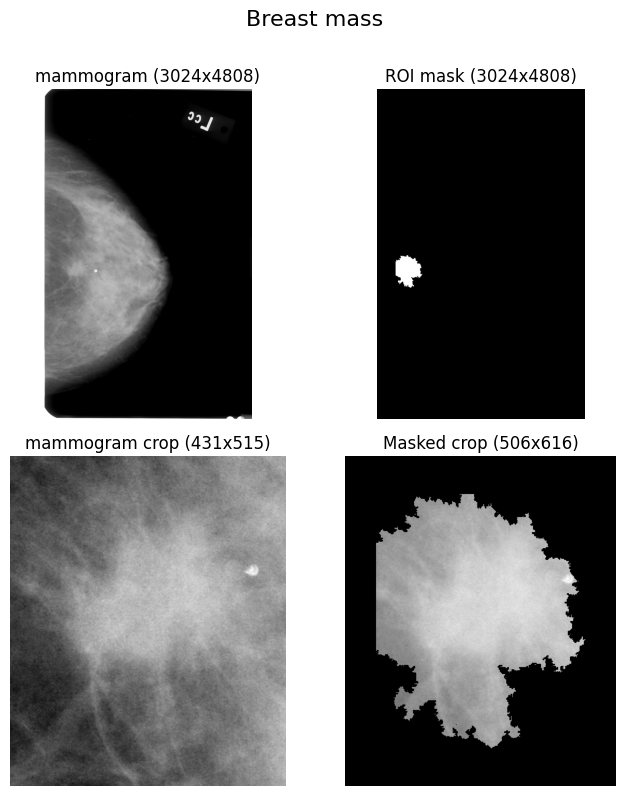

In [3]:
import matplotlib.pyplot as plt
from src.utils.image_utils import resolve_mammogram_path, resolve_cropped_mammogram_path, resolve_roi_mask_path, load_dicom, extract_roi_crop

row_mass = mass_train_df.iloc[0]

mammogram_path_mass = resolve_mammogram_path(row_mass["image file path"])
mammogram_mass = load_dicom(mammogram_path_mass)

roi_mask_path_mass = resolve_roi_mask_path(row_mass["ROI mask file path"])
roi_mask_mass = load_dicom(roi_mask_path_mass)

cropped_mammogram_path_mass = resolve_cropped_mammogram_path(row_mass["cropped image file path"])
cropped_mammogram_mass = load_dicom(cropped_mammogram_path_mass)

masked_crop_mass = extract_roi_crop(mammogram_mass, roi_mask_mass)

fig, axes = plt.subplots(2, 2, figsize=(7, 8))
for ax, img, title in zip(axes.ravel(),
    [mammogram_mass, roi_mask_mass, cropped_mammogram_mass, masked_crop_mass],
    [f'mammogram ({mammogram_mass.shape[1]}x{mammogram_mass.shape[0]})',
     f'ROI mask ({roi_mask_mass.shape[1]}x{roi_mask_mass.shape[0]})',
     f'mammogram crop ({cropped_mammogram_mass.shape[1]}x{cropped_mammogram_mass.shape[0]})',
     f'Masked crop ({masked_crop_mass.shape[1]}x{masked_crop_mass.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    
plt.subplots_adjust(wspace=0.02, hspace=0.05) 
plt.suptitle("Breast mass", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

The full mammogram, cropped image, ROI mask and ROI mask applied to the mammogram of the first Breast Calcification of the dataset:

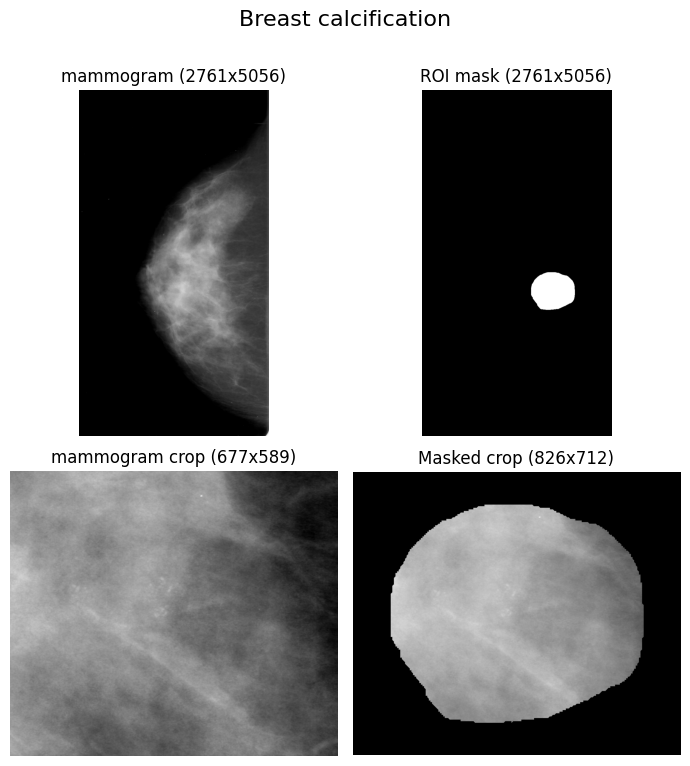

In [47]:
row_calc = calc_train_df.iloc[0]

mammogram_path_calc = resolve_mammogram_path(row_calc["image file path"])
mammogram_calc = load_dicom(mammogram_path_calc)

roi_mask_path_calc = resolve_roi_mask_path(row_calc["ROI mask file path"])
roi_mask_calc = load_dicom(roi_mask_path_calc)

cropped_mammogram_path_calc = resolve_cropped_mammogram_path(row_calc["cropped image file path"])
cropped_mammogram_calc = load_dicom(cropped_mammogram_path_calc)

masked_crop_calc = extract_roi_crop(mammogram_calc, roi_mask_calc)

fig, axes = plt.subplots(2, 2, figsize=(7, 8))
for ax, img, title in zip(axes.ravel(),
    [mammogram_calc, roi_mask_calc, cropped_mammogram_calc, masked_crop_calc],
    [f'mammogram ({mammogram_calc.shape[1]}x{mammogram_calc.shape[0]})',
     f'ROI mask ({roi_mask_calc.shape[1]}x{roi_mask_calc.shape[0]})',
     f'mammogram crop ({cropped_mammogram_calc.shape[1]}x{cropped_mammogram_calc.shape[0]})',
     f'Masked crop ({masked_crop_calc.shape[1]}x{masked_crop_calc.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    
plt.subplots_adjust(wspace=0.02, hspace=0.05) 
plt.suptitle("Breast calcification", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

After this preliminar investigation, some decisions were made: 

1. Only to work with the breast masses images, and not using the calcificaiton ones. That is because both kinds of lesions look very different, and training with them may add too much noise to our model. 
2. Which image to feed the cropped image to the Visual Transformer: the full mammogram, the cropped image or the masked mammogram. Since the Visual Transformer takes the image, in 224x224 resolution, then crops it into smaller 16x16 squares and that is what is fed to the model, the cropped mammogram has the most information in the smallest area. Using full mammograms (~4800×3000) resized to 224×224 would shrink the lesion to a few pixels, and the masked image has a lot of pixels that are fully black and removes part of the context that the cropped image has. The other papers cited in the State of the art section use the cropped mammograms too, making the results more comparable.
3. Which image to compute topological descriptors from. We will compare the results both with the mammogram crop and the mask applied, and see how both of them perform.

## Implementation <a id="implementation"></a>

This section covers the project structure, implementation details, from general to more specific, which experiments will be performed and how that implementation is used in the different experiments.

This project is structured amongst different folders, and it is implemented .py files. For reproducibility purposes, the seed has been fixed in all models to be 2.

### Project structure <a id="structure"></a>

The project structure is the following

```
.
├── data                    <- Images
│   ├── raw                 <- Dataset images in dcm format
│   ├── raw_np              <- Dataset images in np format
│   ├── tda                 <- Topological descriptors of the images
│   └── preprocessed        <- Preprocessed images  
├── src
│   ├── datasets            <- Implements torch.dataset
│   ├── models              <- Implements nn.Module for the ViT and ViT + TDA
│   ├── tda                 <- To compute topological descriptors
│   ├── training            <- To train and evaluate the model
│   └── utils               <- Image processing utils
├── checkpoints             <- Experiment results
├── .gitignore
├── notebook.ipynb          <- This notebook 
├── notebook.html           <- This notebook, exported to html 
├── README.md               <- Setup instructions and brief description of the project
├── requirements.txt        <- List of dependencies
└── TFM.pdf                 <- Msc. Thesis
```

### Implementation details <a id="details"></a>

In a file-by-file analysis:

* **` notebook.ipynb`:** this notebook. Describes the project and triggers the experiment execution. 
* **`src/utils/image_utils.py`:** has seven functions to take care of image loading and path resolution:
  * `load_dicom(path)`: given a full path, it uses [pydicom](https://pydicom.github.io/) to load the image and transform it into a [numpy matrix](https://numpy.org/). It normalizes the image to have values between 0 and 255.
  * `get_all_dcm_files_with_size(rel_path)`: given a relative path, it builds the full path using the `BASE_PATH` defined in the same `image_utils.py` file, whilst taking into account the long path limitations in Windows OS. With the [os](https://docs.python.org/3/library/os.html) module it extracts all files with .dcm extension in said path, and sorts them by size (as described above, it will be used to distinguish masks from cropped mammograms).
  * `resolve_mammogram_path(rel_path)`: extracts the mammogram path from a relative path, taking into account that the file name might be wrong. If more than one files are found in the provided folder, it raises an exception.
  * `resolve_cropped_mammogram_path(rel_path)`: extracts the cropped mammogram path from a relative path, taking into account that the file name might be wrong. If one file is found in the path, it returns the path. If two files are found, it returns the path to the smallest one. If more than two files are found in the provided folder, it raises an exception.
  * `resolve_roi_mask_path(rel_path)`: extracts the ROI mask path from a relative path, taking into account that the file name might be wrong. If one file is found in the path, it returns the path. If two files are found, it returns the path to the biggest one. If more than two files are found in the provided folder, it raises an exception.
  * `cache_cropped_mammogram_images_as_np_arrays(save_dir, df)`: given a dataset with "cropped image file path" and "pathology" columns, it (1) resolves all the paths to the cropped mammography images (2) converts them into numpy arrays and saves them in the `save_dir` provided and (3) saves a `.csv` file in that same folder with two columns: path to the converted image and the corresponding label, that is 1 if it is malignant and 0 if it is either benign or Benign without callback. This function is used to reduce the time loading `dcm` files for every execution.
  * `extract_roi_crop(mammogram, mask, padding_ratio=0.15)`: extracts the ROI crop from a mammogram and applies the mask to it.
* **`src/utils/preprocess.py`:** contains three functions for image preprocessing:
  * `apply_clahe(image)`: applies [Contrast Limited Adaptive Histogram Equalization (CLAHE)](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html) to a grayscale image using [OpenCV's createCLAHE](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html) with `clipLimit=2.0` and `tileGridSize=(8,8)` (the values suggested in the documentation) to enhance local contrast.
  * `denoise(image)`: applies a [Gaussian blur](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html) with a 5×5 kernel using [cv2.GaussianBlur](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.htmll) to reduce noise.
  * `preprocess(image)`: chains `apply_clahe` followed by `denoise`, returning the preprocessed image.
* **`src/models/vit_model.py`:** defines the `ViTClassifier` class, a [PyTorch nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) that wraps a pretrained Vision Transformer. It uses [timm.create_model](https://huggingface.co/docs/timm/reference/models#timm.create_model) to load [vit_base_patch16_224](https://huggingface.co/google/vit-base-patch16-224) (ViT-B/16, pretrained on ImageNet). The classification head is replaced with a single [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer that maps from the ViT's hidden dimension (768) to 1 output (binary classification logit). The `forward` method passes the input through the full ViT and returns the raw logit (during training [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) computes the loss wiht a Sigmoid and BCE).
* **`src/models/fusion_model.py`:** TODO: REVIEW defines the `FusionModel` class, a [PyTorch nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) that combines ViT image features with TDA topological features. It loads the same `vit_base_patch16_224` backbone but replaces the head with [nn.Identity](https://pytorch.org/docs/stable/generated/torch.nn.Identity.html) to extract the 768-dimensional feature vector. A separate TDA branch (`tda_fc`, an [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer) projects the persistence image vector to 128 dimensions. The `forward` method concatenates both feature vectors using [torch.cat](https://pytorch.org/docs/stable/generated/torch.cat.html) and passes the result through a classifier head: `Linear(896, 256) → ReLU → Linear(256, 1)`. Note: the `tda_fc` input dimension is hardcoded to 100 as a placeholder and is overridden at runtime by the experiment cells.
* **`src/datasets/experiment_dataset.py`:** TODO: review defines the `ExperimentDataset` class, a [PyTorch Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) that loads precomputed `.npy` images using [numpy.load](https://numpy.org/doc/stable/reference/generated/numpy.load.html). It optionally applies the preprocessing pipeline from `preprocess.py`, and optionally applies data augmentation (random horizontal and vertical flips using [numpy.fliplr](https://numpy.org/doc/stable/reference/generated/numpy.fliplr.html) and [numpy.flipud](https://numpy.org/doc/stable/reference/generated/numpy.flipud.html)). Images are resized to 224×224 using [cv2.resize](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html), stacked to 3 channels (grayscale → RGB), normalized to [0, 1], and converted to [torch.Tensor](https://pytorch.org/docs/stable/tensors.html). If TDA paths are provided, it also loads the persistence image vector and returns a 3-tuple `(image, tda, label)` instead of `(image, label)`. TODO add aggresive data augmentation
* **`src/training/experiment_runner.py`:** contains the full training pipeline with four functions:
  * `get_class_weights(labels)`: computes `pos_weight` for [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) as the ratio of negative to positive samples, addressing class imbalance in the dataset.
  * `train_one_epoch(model, dataloader, optimizer, criterion, device)`: runs one training epoch. Calls `model.train()`, iterates over batches, computes loss, backpropagates, and updates weights. Handles both 2-tuple (ViT-only) and 3-tuple (fusion) batches.
  * `evaluate(model, dataloader, criterion, device)`: runs evaluation with `model.eval()` and [torch.no_grad](https://pytorch.org/docs/stable/generated/torch.no_grad.html). Computes loss, applies [torch.sigmoid](https://pytorch.org/docs/stable/generated/torch.sigmoid.html) to get probabilities, and calculates [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), and [AUC-ROC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) using [scikit-learn](https://scikit-learn.org/). Returns metrics, true labels, and predicted probabilities.
  * `run_experiment(model_fn, train_dataset, test_dataset, config)`: orchestrates a full experiment. Splits training data into train/val using [StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) (85/15). Creates [DataLoaders](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader), initializes the model, loss (with class weights), [Adam optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), and [CosineAnnealingLR scheduler](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html). Trains with early stopping (patience-based on validation loss), saves the best model checkpoint using [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html), evaluates on the test set, and persists all results (metrics, training history, predictions) to a JSON file using [json.dump](https://docs.python.org/3/library/json.html#json.dump) for survival across kernel restarts.
* **`src/tda/tda_features.py`:** defines `compute_persistence_image(image)`, which computes topological descriptors from a grayscale image. It uses [CubicalPersistence](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/homology/gtda.homology.CubicalPersistence.html) from [giotto-tda](https://giotto-ai.github.io/gtda-docs/latest/) to compute persistent homology (tracking connected components and holes across intensity thresholds), then transforms the resulting persistence diagram into a fixed-size [PersistenceImage](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/diagrams/gtda.diagrams.PersistenceImage.html) vector suitable for machine learning. Used in experiments E3–E8.
* **`checkpoints/*_results.json`:** JSON files persisted by `run_experiment()` after each experiment. Each file contains: test metrics (loss, accuracy, F1, AUC), training history (train loss, val loss, val AUC per epoch), the checkpoint path, and the raw test predictions (`y_true`, `y_prob`) for confusion matrices and ROC curves.


### Experiments <a id="experiments"></a>
The first hypothesis to be tested is 

<p style="text-align:center"><i> <strong>H1:</strong> Image preprocessing techniques (noise reduction and contrast enhancement) positively impact the classification accuracy of a Vision Transformer model. </i></p>

To do so, we define three experiments:

|Id|Experiment name|Description|
|-|-|-|
|E1|ViT baseline|ViT model with no preprocessing, data augmentation applied to the training set|
|E2|ViT preprocessing|E1 + CLAHE and Denoise, defined in `preprocess.py`|
|E3|ViT preprocessing + aggressive data augmentation|E2 + aggressive data augmentation applied to the training set|

The results of these experiments are compared to the ones cited in the state of the art portion of the thesis.

| Study | AUC | ACC | F1 |
|-------|-----|-----|----|
| Paper 1 (VGG16 + heavy augmentation to 60K images) | 0.844 | 0.844 | 0.85 |
| Paper 2 (EfficientNet-B2, minimal augmentation) | 0.679 | 0.650 | — |
| Paper 3 (BiT + attention + text metadata) | 0.878 | 0.796 | 0.780 |

It is specially interesting how the results from E1 and E2 compare to Papers 1 and 2, and to see E3 compared with Paper 1 and Paper 3. As defined above, the ViT will be fed the mammogram cropped images.

The second hypothesis to be tested is:

<p style="text-align:center"><i> <strong>H2:</strong> The incorporation of topological descriptors derived from TDA provides complementary structural information that improves classification performance compared to a standard Vision Transformer.</i></p>

To test this, persistence images will be computed for every image and fed into the Visual Transformer. The experiments performed are the following:

|Id|Experiment name|Description|
|-|-|-|
|E4|ViT baseline + TDA in mammography crop|E1 fed with the mammography crops and persistance images of said crops|
|E5|ViT baseline + TDA in masked mammography|E1 fed with the mammography crops and persistance images of the masked mammography|

E4 and E5 allows us to see which of the embeddings gets better results, and to compare them with E1.
Depending on the results obtained, E4b and E5b will be ran.

|Id|Experiment name|Description|
|-|-|-|
|E4b|ViT baseline + preprocessing + TDA in mammography crop|E2 fed with the mammography crops and persistance images of said crops|
|E5b|ViT baseline + preprocessing + TDA in masked mammography|E2 fed with the mammography crops and persistance images of the masked mammography|

Lastly, we combine the best of the first three experiments with the best of the last 2 to craft the best model possible with these tools.

|Id|Experiment name|Description|
|-|-|-|
|E6|Best|Best in (E1, E2, E3) + Best in (E4, E5)|

#### Preprocessing <a id="preprocessing"></a>

To relieve the load in the training that comes from loading dcm files, first we transform all of them into normalized numpy arrays and store them in `data/raw_np/mass_<train/test>`

The persistance images computed for every cropped mammogram are stored in `data/tda/mass_<train/test>`. To add clarity, the first cell shows what persistance images look like for a mammograph.

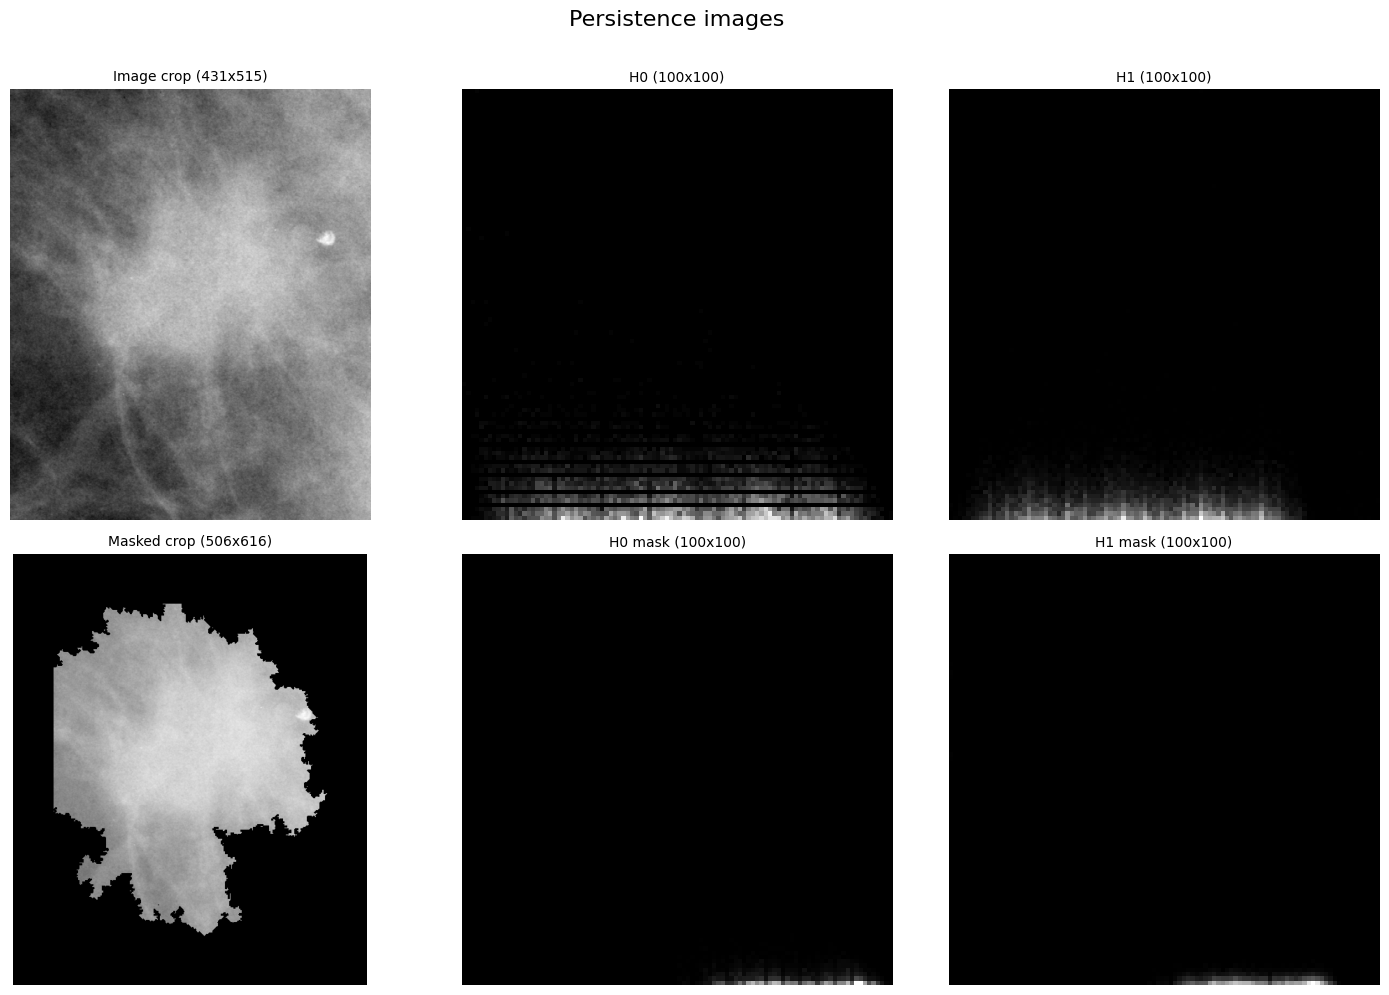

In [4]:
from src.tda.tda_features import compute_persistence_image

pi_0, pi_1 = compute_persistence_image(cropped_mammogram_mass)
pi_0_mask, pi_1_mask = compute_persistence_image(masked_crop_mass)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, im, title in zip(
    axes.ravel(),
    [cropped_mammogram_mass, pi_0, pi_1,
     masked_crop_mass, pi_0_mask, pi_1_mask],
    [f'Image crop ({cropped_mammogram_mass.shape[1]}x{cropped_mammogram_mass.shape[0]})',
     f'H0 ({pi_0.shape[1]}x{pi_0.shape[0]})',
     f'H1 ({pi_1.shape[1]}x{pi_1.shape[0]})',
     f'Masked crop ({masked_crop_mass.shape[1]}x{masked_crop_mass.shape[0]})',
     f'H0 mask ({pi_0_mask.shape[1]}x{pi_0_mask.shape[0]})',
     f'H1 mask ({pi_1_mask.shape[1]}x{pi_1_mask.shape[0]})']
):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.15)
plt.suptitle("Persistence images", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

In [5]:
MASS_TRAIN_SAVE_DIR = "data/raw_np/mass_train"
MASS_TEST_SAVE_DIR = "data/raw_np/mass_test"

MASS_TRAIN_TDA_CROP_DIR = "data/tda/crop/mass_train"
MASS_TEST_TDA_CROP_DIR = "data/tda/crop/mass_test"
MASS_TRAIN_TDA_MASKED_DIR = "data/tda/masked/mass_train"
MASS_TEST_TDA_MASKED_DIR = "data/tda/masked/mass_test"

In [ ]:
from src.utils.image_utils import cache_cropped_mammogram_images_as_np_arrays

cache_cropped_mammogram_images_as_np_arrays(MASS_TRAIN_SAVE_DIR, mass_train_df)
cache_cropped_mammogram_images_as_np_arrays(MASS_TEST_SAVE_DIR, mass_test_df)

1318it [00:04, 310.27it/s]
378it [00:01, 301.21it/s]


In [ ]:
from src.tda.tda_features import precompute_tda_cropped_image, precompute_tda_masked_mammography

# Precompute TDA for cropped lesions (E4)
precompute_tda_cropped_image(MASS_TRAIN_SAVE_DIR + '/cached.csv', MASS_TRAIN_TDA_CROP_DIR)
precompute_tda_cropped_image(MASS_TEST_SAVE_DIR + '/cached.csv', MASS_TEST_TDA_CROP_DIR)

# Precompute TDA for masked crops (E5)
precompute_tda_masked_mammography(MASS_TRAIN_SAVE_DIR + '/cached.csv', mass_train_df, MASS_TRAIN_TDA_MASKED_DIR)
precompute_tda_masked_mammography(MASS_TEST_SAVE_DIR + '/cached.csv', mass_test_df, MASS_TEST_TDA_MASKED_DIR)

print('All TDA precomputation done.')

#### Execution <a id="execution"></a>

TODO

In [3]:
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

SEED = 2
# Load the cached pre-cropped lesion paths from Step 1
train_cache = pd.read_csv(MASS_TRAIN_SAVE_DIR + '/cached.csv')
test_cache = pd.read_csv(MASS_TEST_SAVE_DIR + '/cached.csv')

results = {}

In [ ]:
# --- E1: ViT baseline (no preprocessing, no TDA) ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=False, augment=False)

results['E1'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E1: ViT baseline ===
  [E1] Epoch 1/30  train_loss=0.7776  val_loss=0.7135  val_auc=0.5826
  [E1] Epoch 2/30  train_loss=0.7526  val_loss=0.7199  val_auc=0.5964
  [E1] Epoch 3/30  train_loss=0.7255  val_loss=0.7251  val_auc=0.6041
  [E1] Epoch 4/30  train_loss=0.7351  val_loss=0.7867  val_auc=0.6053
  [E1] Epoch 5/30  train_loss=0.7332  val_loss=0.7161  val_auc=0.6120
  [E1] Epoch 6/30  train_loss=0.7224  val_loss=0.7146  val_auc=0.6283
  [E1] Early stopping at epoch 6
  [E1] TEST  acc=0.3995  f1=0.5505  auc=0.5346


### Step 2: Run experiment E2
E2: ViT + preprocessing (CLAHE + denoise), no TDA.  
Same data as E1, but with preprocessing applied on the fly.

In [10]:
# --- E2: ViT + preprocessing ---
print('=== E2: ViT + preprocessing ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=True, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=True, augment=False)

results['E2'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E2', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E2: ViT + preprocessing ===
  [E2] Epoch 1/30  train_loss=0.7946  val_loss=0.7128  val_auc=0.6078
  [E2] Epoch 2/30  train_loss=0.7487  val_loss=0.7188  val_auc=0.6515
  [E2] Epoch 3/30  train_loss=0.7236  val_loss=0.7191  val_auc=0.6746
  [E2] Epoch 4/30  train_loss=0.7349  val_loss=0.7758  val_auc=0.6649
  [E2] Epoch 5/30  train_loss=0.7286  val_loss=0.7039  val_auc=0.6779
  [E2] Epoch 6/30  train_loss=0.7093  val_loss=0.7264  val_auc=0.6736
  [E2] Epoch 7/30  train_loss=0.7106  val_loss=0.7451  val_auc=0.6567
  [E2] Epoch 8/30  train_loss=0.7155  val_loss=0.6868  val_auc=0.6637
  [E2] Epoch 9/30  train_loss=0.6934  val_loss=0.6947  val_auc=0.6326
  [E2] Epoch 10/30  train_loss=0.6923  val_loss=0.7035  val_auc=0.6119
  [E2] Epoch 11/30  train_loss=0.7063  val_loss=0.6810  val_auc=0.6748
  [E2] Epoch 12/30  train_loss=0.6817  val_loss=0.6745  val_auc=0.6681
  [E2] Epoch 13/30  train_loss=0.7014  val_loss=0.7148  val_auc=0.6600
  [E2] Epoch 14/30  train_loss=0.6835  val_loss=0.7140

### E3: ViT + preprocessing + aggressive data augmentation
Same as E2 but with aggressive augmentation: random rotations (±15°), random zoom/crop (85–100%), random shear (±0.1), in addition to flips. This tests whether heavier augmentation (as used in Paper 1) further improves results.

In [4]:
# --- E3: ViT + preprocessing + aggressive augmentation ---
print('=== E3: ViT + preprocessing + aggressive augmentation ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=True, augment=True, aggressive_augmentation=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=True, augment=False, aggressive_augmentation=False)

results['E3'] = run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E3', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E3: ViT + preprocessing + aggressive augmentation ===
  [E3] Epoch 1/30  train_loss=0.7632  val_loss=0.7144  val_auc=0.5869
  [E3] Epoch 2/30  train_loss=0.7612  val_loss=0.7331  val_auc=0.5895
  [E3] Epoch 3/30  train_loss=0.7258  val_loss=0.7256  val_auc=0.6373
  [E3] Epoch 4/30  train_loss=0.7374  val_loss=0.7892  val_auc=0.6189
  [E3] Epoch 5/30  train_loss=0.7334  val_loss=0.7160  val_auc=0.6253
  [E3] Epoch 6/30  train_loss=0.7216  val_loss=0.7099  val_auc=0.6162
  [E3] Epoch 7/30  train_loss=0.7201  val_loss=0.7283  val_auc=0.6614
  [E3] Epoch 8/30  train_loss=0.7307  val_loss=0.7252  val_auc=0.6298
  [E3] Epoch 9/30  train_loss=0.7149  val_loss=0.7109  val_auc=0.6208
  [E3] Epoch 10/30  train_loss=0.7304  val_loss=0.7122  val_auc=0.6436
  [E3] Epoch 11/30  train_loss=0.7207  val_loss=0.6938  val_auc=0.6746
  [E3] Epoch 12/30  train_loss=0.7202  val_loss=0.7212  val_auc=0.5910
  [E3] Epoch 13/30  train_loss=0.7429  val_loss=0.7470  val_auc=0.6016
  [E3] Epoch 14/30  train_lo

## E1 and E2 Analysis

### E1 (ViT baseline, no preprocessing)
- Trained for 6 epochs (early stopping triggered)
- **Test: ACC=0.3995, F1=0.5505, AUC=0.5346**
- Very poor — barely above random (AUC 0.5)

### E2 (ViT + CLAHE + denoise)
- Trained for 26 epochs (early stopping at epoch 26)
- **Test: ACC=0.6720, F1=0.6196, AUC=0.7228**
- Significantly better than E1

### Comparison with cited papers
| Study | AUC | ACC | F1 |
|-------|-----|-----|----|
| Paper 1 (VGG16 + heavy augmentation to 60K images) | 0.844 | 0.844 | 0.85 |
| Paper 2 (EfficientNet-B2, minimal augmentation) | 0.679 | 0.650 | — |
| Paper 3 (BiT + attention + text metadata) | 0.878 | 0.796 | 0.780 |
| **E1 (ours)** | **0.535** | **0.400** | **0.550** |
| **E2 (ours)** | **0.723** | **0.672** | **0.620** |

### Why E1 is so bad
- ViT-B/16 was pretrained on ImageNet (natural images), not medical images
- Without preprocessing, mammographic images have very low contrast — the pretrained features don't transfer well to raw mammograms
- The dataset is small (~1K train samples) — ViT needs large data
- Only basic augmentation (flip) was used

### Why E2 is much better
- CLAHE dramatically enhances tissue contrast, making pretrained ViT features useful
- E2 is competitive with Paper 2 (which also used minimal augmentation)
- The gap to Papers 1 and 3 is explained by their much heavier augmentation and additional data

### Conclusion
**The E1→E2 improvement (AUC 0.53 → 0.72) strongly supports hypothesis H1**: preprocessing makes a huge difference for ViT-based mammogram classification.

### E4: ViT baseline + TDA on pre-cropped lesion
Uses the FusionModel: ViT processes the raw cropped image, TDA branch processes persistence images computed from the same cropped image (precomputed above). Tests whether topological features of the full crop add information.

In [ ]:
# --- E4: ViT (raw) + TDA on cropped lesion ---
import numpy as np, pandas as pd, torch.nn as nn
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.fusion_model import FusionModel
from src.training.experiment_runner import run_experiment

train_cache = pd.read_csv(MASS_TRAIN_SAVE_DIR + '/cached.csv')
test_cache = pd.read_csv(MASS_TEST_SAVE_DIR + '/cached.csv')

sample_pi = np.load(train_cache['tda_crop_path'].iloc[0])
pi_dim = sample_pi.flatten().shape[0]
print(f'PI dimension (crop): {pi_dim}')

def make_fusion_model(tda_input_dim):
    def fn():
        model = FusionModel()
        model.tda_fc = nn.Linear(tda_input_dim, 128)
        return model
    return fn

print('=== E4: ViT (raw) + TDA on cropped lesion ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_crop_path'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_crop_path'].tolist(),
    use_preprocessing=False, augment=False)

results['E4'] = run_experiment(
    model_fn=make_fusion_model(pi_dim),
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E4', 'seed': SEED, 'epochs': 30, 'patience': 5})

### E5: ViT baseline + TDA on masked mammography
Uses the FusionModel: ViT processes the raw cropped image, TDA branch processes persistence images computed from the masked crop (precomputed above). Tests whether lesion-specific topology is more informative than full-crop topology.

In [ ]:
# --- E5: ViT (raw) + TDA on masked crop ---
import numpy as np, pandas as pd, torch.nn as nn
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.fusion_model import FusionModel
from src.training.experiment_runner import run_experiment

train_cache = pd.read_csv(MASS_TRAIN_SAVE_DIR + '/cached.csv')
test_cache = pd.read_csv(MASS_TEST_SAVE_DIR + '/cached.csv')

sample_pi = np.load(train_cache['tda_masked_path'].iloc[0])
pi_dim_masked = sample_pi.flatten().shape[0]
print(f'PI dimension (masked): {pi_dim_masked}')

def make_fusion_model(tda_input_dim):
    def fn():
        model = FusionModel()
        model.tda_fc = nn.Linear(tda_input_dim, 128)
        return model
    return fn

print('=== E5: ViT (raw) + TDA on masked crop ===')
train_ds = ExperimentDataset(
    roi_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_masked_path'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    roi_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_masked_path'].tolist(),
    use_preprocessing=False, augment=False)

results['E5'] = run_experiment(
    model_fn=make_fusion_model(pi_dim_masked),
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E5', 'seed': SEED, 'epochs': 30, 'patience': 5})

## Results <a id="results"></a>

TODO: WRITE


In [5]:
import json, os, glob
import pandas as pd

results = {}
for path in sorted(glob.glob('checkpoints/*_results.json')):
    name = os.path.basename(path).replace('_results.json', '')
    with open(path) as f:
        results[name] = json.load(f)

if results:
    rows = []
    for name, r in sorted(results.items()):
        t = r['test']
        rows.append({
            'Experiment': name,
            'Accuracy': f"{t['accuracy']:.4f}",
            'F1': f"{t['f1']:.4f}",
            'AUC': f"{t['auc']:.4f}",
            'Test Loss': f"{t['loss']:.4f}"
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('No results found in checkpoints/. Run experiments first.')

Experiment Accuracy     F1    AUC Test Loss
        E1   0.3995 0.5505 0.5346    0.7179
        E2   0.6720 0.6196 0.7228    0.6516
        E3   0.6138 0.5101 0.6556    0.6893


### Learning curves

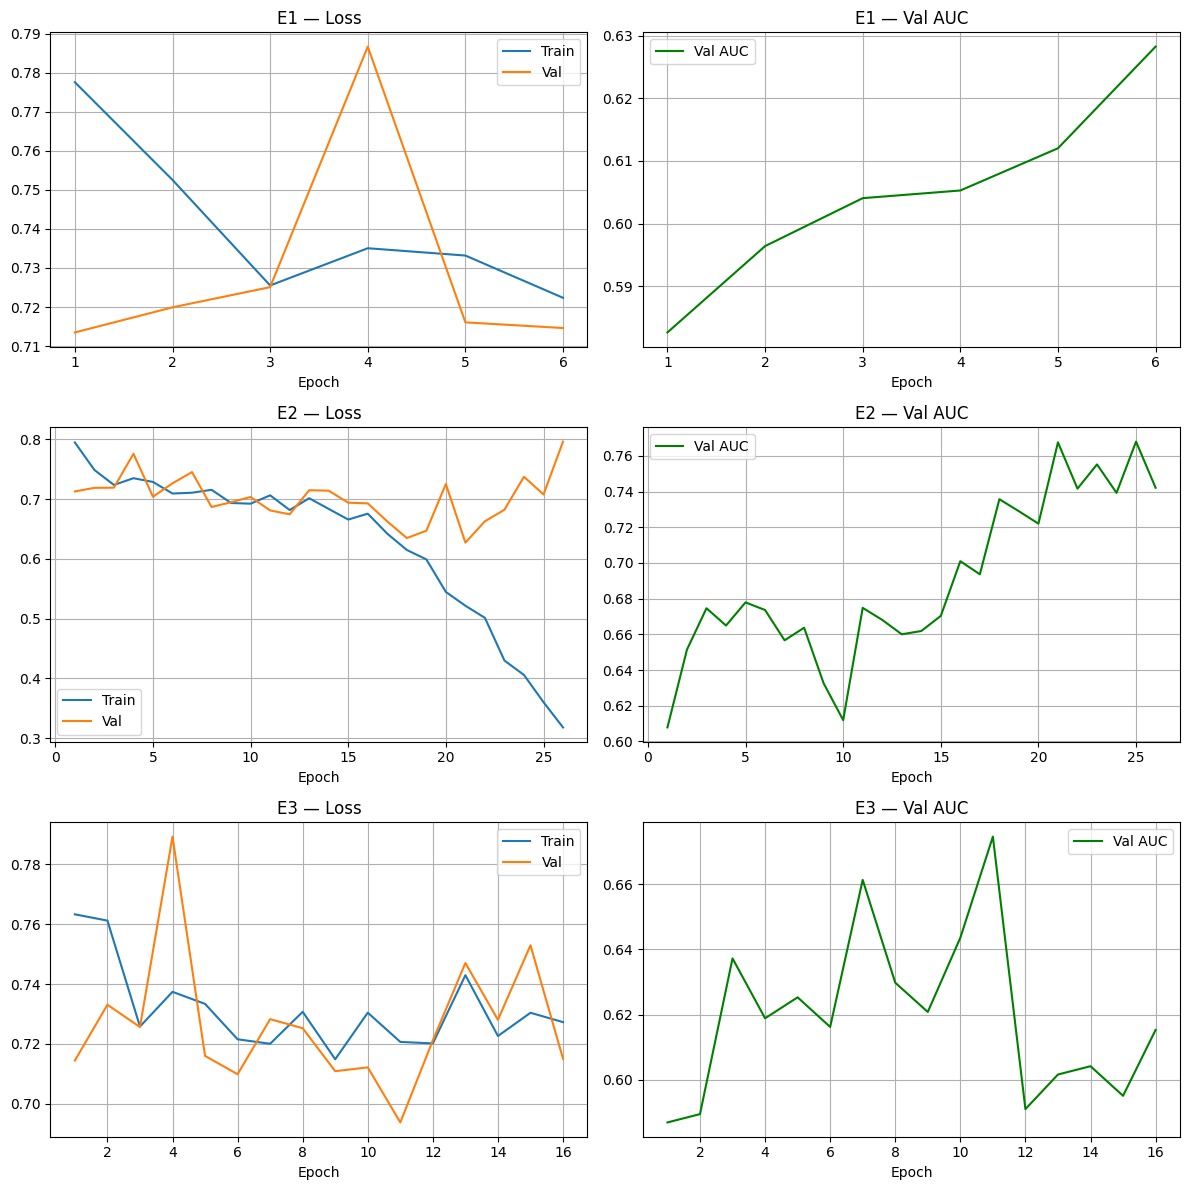

In [6]:
import matplotlib.pyplot as plt

if results:
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    for i, (name, r) in enumerate(sorted(results.items())):
        h = r['history']
        epochs = range(1, len(h['train_loss']) + 1)
        # Loss
        axes[i][0].plot(epochs, h['train_loss'], label='Train')
        axes[i][0].plot(epochs, h['val_loss'], label='Val')
        axes[i][0].set_title(f'{name} — Loss')
        axes[i][0].set_xlabel('Epoch')
        axes[i][0].legend()
        axes[i][0].grid(True)
        # AUC
        axes[i][1].plot(epochs, h['val_auc'], label='Val AUC', color='green')
        axes[i][1].set_title(f'{name} — Val AUC')
        axes[i][1].set_xlabel('Epoch')
        axes[i][1].legend()
        axes[i][1].grid(True)
    plt.tight_layout()
    plt.show()

### Confusion matrices & ROC curves

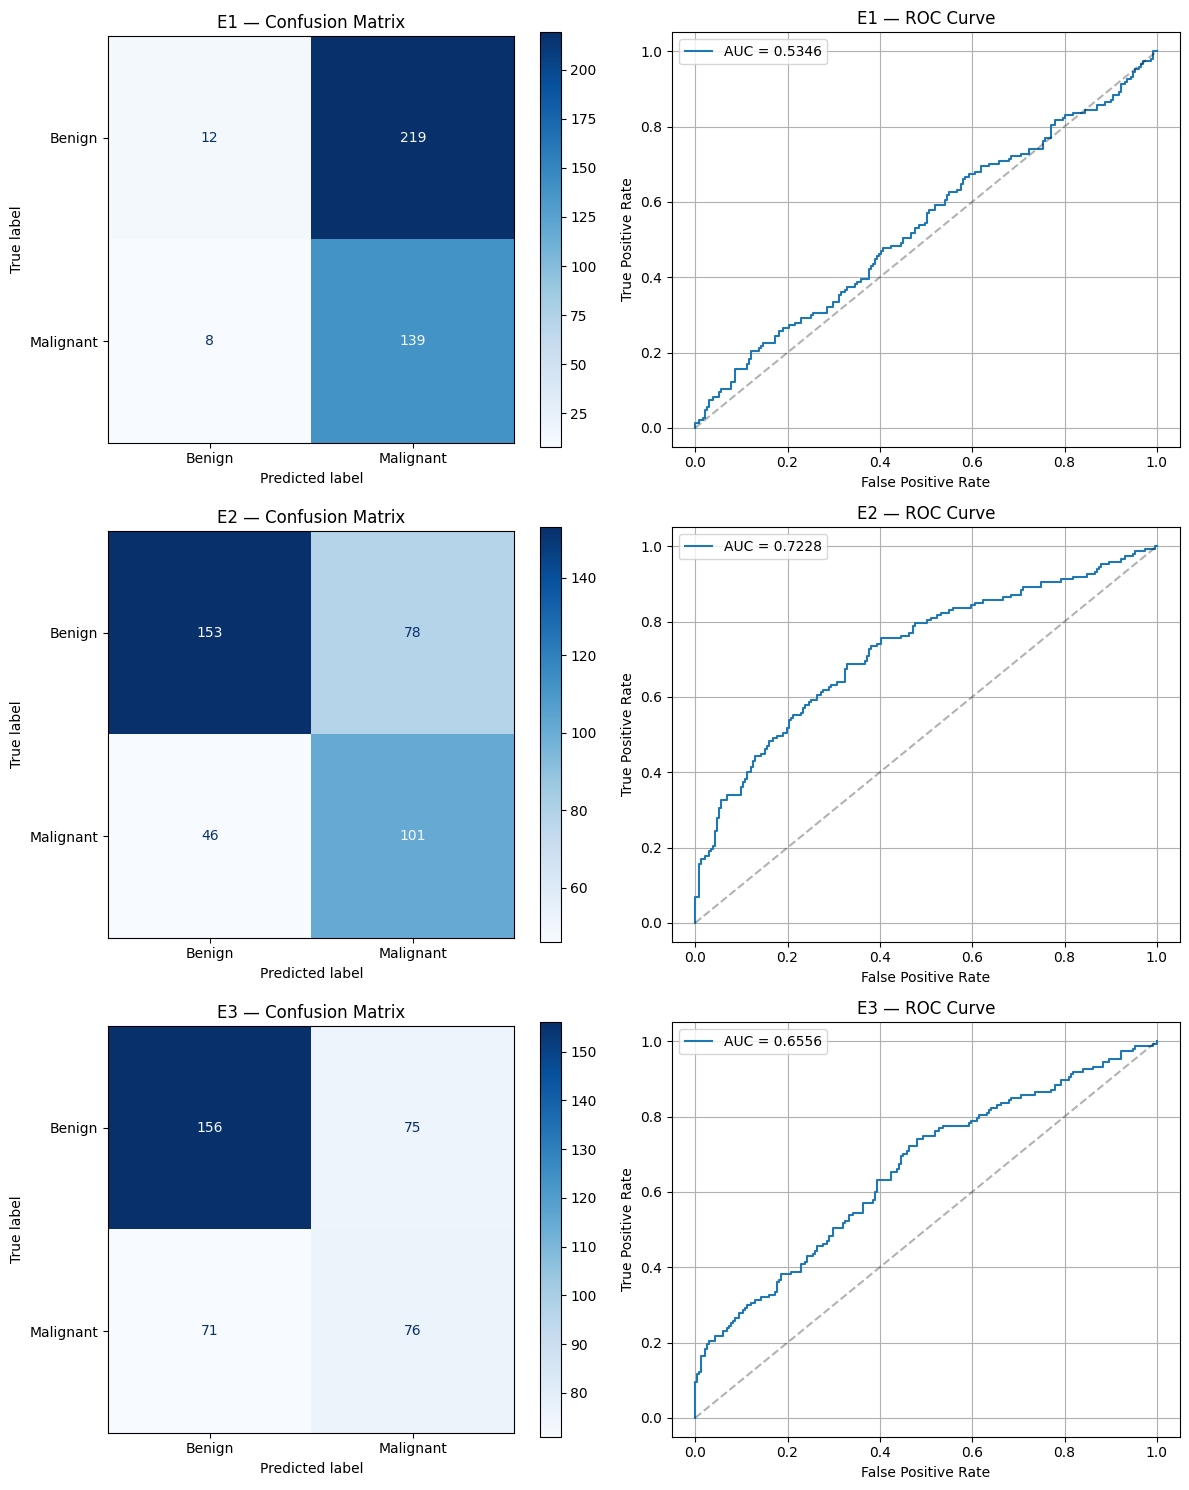

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

if results:
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(12, 5 * n), squeeze=False)
    for i, (name, r) in enumerate(sorted(results.items())):
        if 'y_true' not in r:
            axes[i][0].set_title(f'{name} — no predictions saved')
            continue
        y_true = np.array(r['y_true'])
        y_prob = np.array(r['y_prob'])
        y_pred = (y_prob > 0.5).astype(int)
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=axes[i][0], cmap='Blues')
        axes[i][0].set_title(f'{name} — Confusion Matrix')
        # ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        axes[i][1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
        axes[i][1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[i][1].set_title(f'{name} — ROC Curve')
        axes[i][1].set_xlabel('False Positive Rate')
        axes[i][1].set_ylabel('True Positive Rate')
        axes[i][1].legend()
        axes[i][1].grid(True)
    plt.tight_layout()
    plt.show()